### Demo of CNN for feature extraction

In [6]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [8]:
# Change this if your image has a different filename/path
IMAGE_PATH = "GravLense.jpg"   # or "/mnt/data/GravLense.jpg"

In [10]:
# Load image
img = Image.open(IMAGE_PATH).convert("RGB")
img_arr = np.array(img).astype(np.float32)

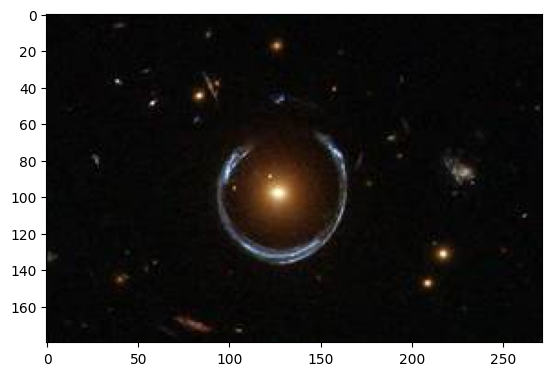

In [12]:
plt.imshow(img)

In [14]:
# Convert RGB image to grayscale
gray = (
    0.299 * img_arr[:, :, 0] +
    0.587 * img_arr[:, :, 1] +
    0.114 * img_arr[:, :, 2]
)

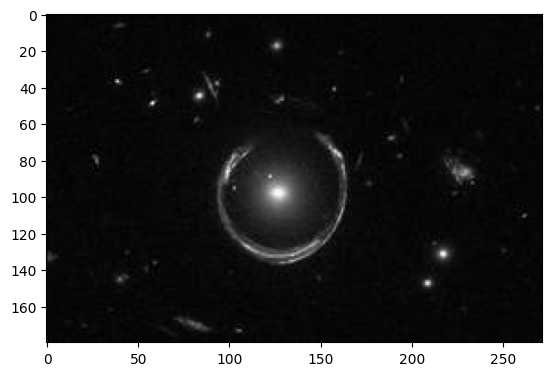

In [20]:
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.show()

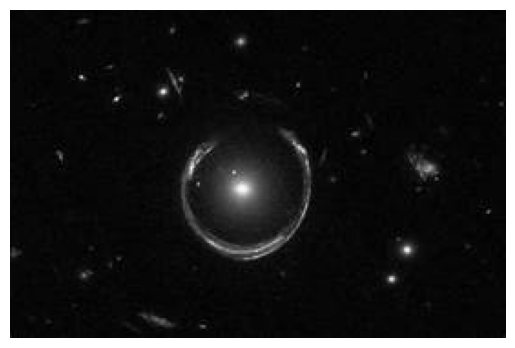

In [22]:
gray_rgb = np.stack([gray, gray, gray], axis=2).astype(np.uint8)

plt.imshow(gray_rgb)
plt.axis("off")
plt.show()

In [24]:
# 3x3 convolution kernel used in the illustration
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

In [26]:
def convolve2d(image, kernel):
    """
    Performs 2D convolution on a grayscale image.
    """
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="edge"
    )

    output = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output

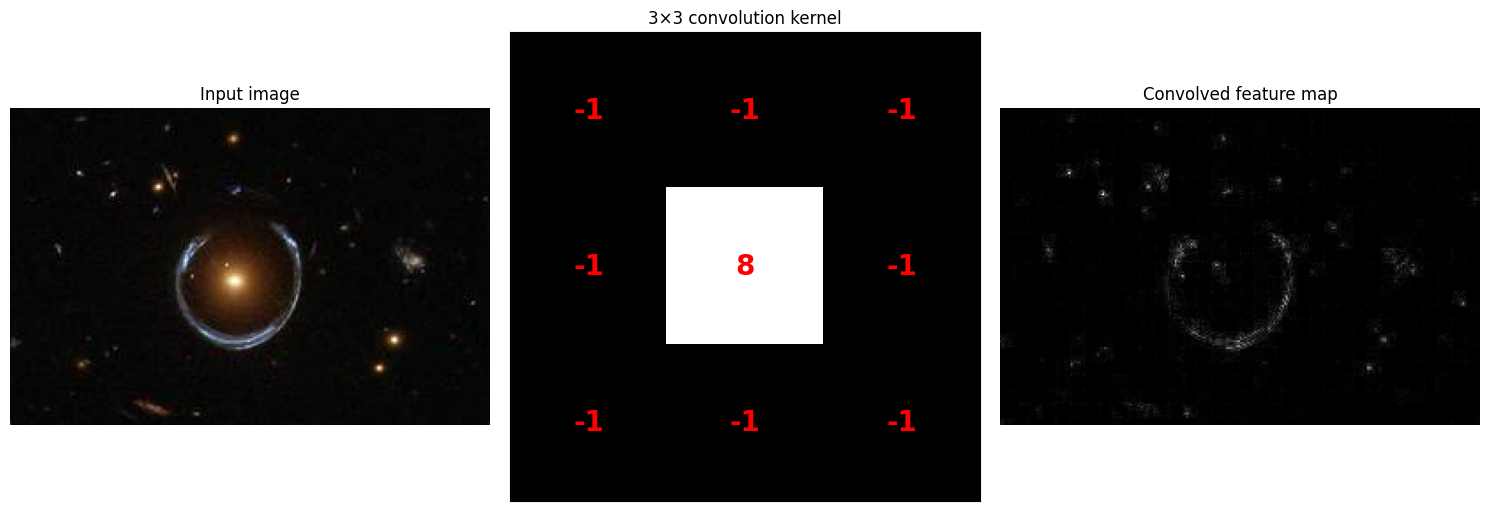

In [28]:
# Apply convolution
convolved = convolve2d(gray, kernel)

# Use absolute values so both dark-to-light and light-to-dark edges show up
feature_map = np.abs(convolved)

# Normalize to 0-255 for display
feature_map = feature_map / feature_map.max()
feature_map = (feature_map * 255).astype(np.uint8)

# Display input image, kernel, and convolved feature map
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_arr.astype(np.uint8))
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(kernel, cmap="gray")
axes[1].set_title("3×3 convolution kernel")
axes[1].set_xticks([])
axes[1].set_yticks([])

for i in range(3):
    for j in range(3):
        axes[1].text(
            j, i, str(int(kernel[i, j])),
            ha="center", va="center",
            color="red", fontsize=20, fontweight="bold"
        )

axes[2].imshow(feature_map, cmap="gray")
axes[2].set_title("Convolved feature map")
axes[2].axis("off")

plt.tight_layout()
plt.show()